<a href="https://colab.research.google.com/github/juancuevas-ops/modelo-predictivo-de-ventas/blob/main/M%C3%B3dulo_de_Inteligencia_de_Mercado_para_Seguridad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ======================================================================
# SICA v2.0: Módulo de Inteligencia de Mercado para Seguridad
# Creado el 19 de junio de 2025
# Objetivo: Identificar debilidades de la competencia y sectores de alta demanda.
# ======================================================================

# --- 1. INSTALACIÓN Y CONFIGURACIÓN ---
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote_plus
import time

# --- 2. CONFIGURACIÓN ---
# Usamos las mismas credenciales que ya funcionaron
api_key = "509e7e7f1c89749f8abc64c40810836a285ce122917ef3eba3b42eb55364a9e"
nombre_de_zona = "federal_serp"

# ==================================================================
# ====> ¡NUEVA LISTA DE BÚSQUEDAS ESTRATÉGICAS! <====
# ==================================================================
consultas_de_busqueda = [
    # --- CATEGORÍA 1: INTELIGENCIA COMPETITIVA (DEBILIDADES DE VERISURE Y ADT) ---
    'site:reclamos.cl "Verisure Chile" "no responden"', # Busca reclamos específicos en el portal más grande de Chile.
    'site:reclamos.cl "ADT Seguridad" "falsa alarma"',
    '"mala experiencia" con alarma Verisure foro Chile', # Busca en foros de discusión.
    '"problemas servicio técnico" ADT Chile',
    'noticias "falla masiva" Verisure', # Busca fallas de alto impacto reportadas en prensa.
    '"demora en llegar" ADT seguridad',

    # --- CATEGORÍA 2: SEGMENTACIÓN GEOGRÁFICA (SECTORES CON MÁS DELINCUENCIA) ---
    'noticias "ola de robos" "Las Condes"', # Comunas de sector oriente.
    'noticias "aumento de portonazos" "Vitacura"',
    'noticias "asaltos a locales comerciales" "Providencia"',
    'mapa de la delincuencia "Santiago Centro"', # Comunas de alta densidad.
    'noticias "robos en casas" "Ñuñoa"',
    'delincuencia "La Florida"', # Comunas populosas.
    'aumento de delitos "Maipú"',
    'informe seguridad ciudadana "Puente Alto"',

    # --- CATEGORÍA 3: BÚSQUEDAS AVANZADAS (CRITERIOS ADICIONALES) ---
    '"informe STOP Carabineros" comunas Santiago', # Busca informes oficiales de Carabineros.
    '"delitos de mayor connotación social" Subsecretaría Prevención del Delito', # Busca datos del gobierno.
    'condominios con problemas de seguridad Santiago', # Busca un nicho de mercado específico.
    'empresas buscan mejorar seguridad corporativa Chile' # Busca clientes B2B.
]


# --- El resto del script es idéntico y funciona igual ---
url_api = "https://api.brightdata.com/request"
headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}
resultados_finales = []
print("Iniciando SICA v2.0: Módulo de Inteligencia de Mercado para Seguridad...")

for consulta in consultas_de_busqueda:
    url_a_scrapear = f"https://www.google.com/search?q={quote_plus(consulta)}&hl=es&gl=cl"
    payload = {"zone": nombre_de_zona, "url": url_a_scrapear, "format": "raw"}
    print(f"\nBuscando: '{consulta}'...")
    response = requests.post(url_api, headers=headers, json=payload)

    if response.status_code == 200:
        html_de_google = response.text
        sopa = BeautifulSoup(html_de_google, 'html.parser')
        selectores_posibles = ["div.g", "div.MjjYud", "div.Ww4FFb", "div.kvH3mc", "div.srg"]
        elementos_resultado = []
        selector_exitoso = ""
        for selector in selectores_posibles:
            elementos_resultado = sopa.select(selector)
            if elementos_resultado:
                selector_exitoso = selector
                break
        print(f"  -> ¡Éxito! Usando '{selector_exitoso}', se encontraron {len(elementos_resultado)} resultados.")
        for elemento in elementos_resultado:
            try:
                titulo_elem = elemento.find('h3')
                enlace_elem = elemento.find('a')
                resumen_elem = elemento.select_one('div.VwiC3b, div.yDYNvb, span.s3v9rd')
                if titulo_elem and enlace_elem and enlace_elem.has_attr('href'):
                    resultados_finales.append({"consulta": consulta, "titulo": titulo_elem.get_text(), "enlace": enlace_elem['href'], "resumen": resumen_elem.get_text(strip=True) if resumen_elem else "N/A"})
            except Exception: continue
    else:
        print(f"  -> La petición falló. Código: {response.status_code}, Respuesta: {response.text}")
    time.sleep(2)

print("\n" + "="*50 + "\nResultados Finales de Inteligencia de Mercado\n" + "="*50)
if resultados_finales:
    for i, res in enumerate(resultados_finales, 1):
        print(f"\n hallazgo #{i}:\n  Búsqueda: {res['consulta']}\n  Título: {res['titulo']}\n  Enlace: {res['enlace']}\n  Resumen: {res['resumen']}")
else:
    print("No se obtuvieron resultados de las búsquedas realizadas.")
print("="*50)

Iniciando SICA v2.0: Módulo de Inteligencia de Mercado para Seguridad...

Buscando: 'site:reclamos.cl "Verisure Chile" "no responden"'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 3 resultados.

Buscando: 'site:reclamos.cl "ADT Seguridad" "falsa alarma"'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 5 resultados.

Buscando: '"mala experiencia" con alarma Verisure foro Chile'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 17 resultados.

Buscando: '"problemas servicio técnico" ADT Chile'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 4 resultados.

Buscando: 'noticias "falla masiva" Verisure'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 7 resultados.

Buscando: '"demora en llegar" ADT seguridad'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 16 resultados.

Buscando: 'noticias "ola de robos" "Las Condes"'...
  -> ¡Éxito! Usando 'div.MjjYud', se encontraron 15 resultados.

Buscando: 'noticias "aumento de portonazos" "Vitacura"'...
  -> ¡Éxito! Usando 'd

#  Análisis de Inteligencia de Mercado para el Crecimiento de Ventas
## Resumen Ejecutivo:
### El análisis de datos públicos revela dos oportunidades estratégicas claras y de alto impacto:

Brecha de Servicio en la Competencia: Existe una marcada y documentada insatisfacción de los clientes de la competencia (especialmente Verisure) centrada en el servicio post-venta, los contratos y los cobros, más que en la tecnología misma. Esto representa una debilidad clave que podemos explotar.
Mapa de Demanda Potencial: Se ha identificado un "mapa de calor" de comunas en Santiago con tipos de delitos específicos y recurrentes, lo que permite una segmentación de mercado precisa y campañas de marketing de alta eficiencia.
A continuación, se detallan los hallazgos y las recomendaciones accionables.

## 1. Inteligencia Competitiva: La Gran Debilidad de Verisure y ADT es su Contrato y Servicio Post-Venta
Los resultados de nuestras búsquedas en reclamos.cl y foros (hallazgos #1, #2, #3, #4, #7, #11) son concluyentes. Los clientes no se quejan principalmente de que las alarmas no suenen; se quejan de:

Contratos con "letra chica" y multas por término anticipado (hallazgo #4).
Cobros excesivos y abusivos (hallazgos #1, #3).
Malas experiencias con vendedores y servicio técnico (hallazgo #5).
Dificultades y demoras para dar de baja el servicio (hallazgos #1, #2).
Incumplimiento de requisitos de aseguradoras (hallazgos #7, #11).
Recomendaciones Accionables:
Acción 1: Crear el "Argumentario del Dolor" para el Equipo de Ventas.

Tu equipo debe estar armado con frases que ataquen directamente estas debilidades.
Ejemplo de discurso: "Entendemos que una de las mayores preocupaciones al contratar una alarma son los contratos con cláusulas escondidas y las dificultades para terminar el servicio. Por eso, en [Tu Empresa], nuestros contratos son transparentes, sin letra chica y con plazos flexibles. Priorizamos su tranquilidad, no solo con tecnología, sino con un servicio justo."
Acción 2: Lanzar una Campaña Digital de "Switch" (Cambio).

Crear anuncios en redes sociales dirigidos a personas que siguen o han interactuado con las páginas de Verisure y ADT.
Mensaje de la campaña: "¿Cansado de un mal servicio y cobros sorpresa en tu sistema de alarma? Es hora de cambiar a la tranquilidad real. Conoce nuestros planes transparentes."
## 2. Segmentación Geográfica: Dónde Apuntar y con Qué Mensaje
Los datos de noticias (hallazgos #26 en adelante) nos dibujan un mapa claro de las necesidades por zona.

# Zonas de Alta Prioridad Identificadas:
Las Condes y Vitacura: Preocupación principal por "ola de robos" y "aumento de portonazos" (hallazgos #26, #33). El perfil de cliente busca proteger su patrimonio y vehículos de alto valor.
Providencia y Santiago Centro: El foco está en "asaltos a locales comerciales" y delitos violentos en zonas de alta densidad (hallazgos #43, #52, #55). El perfil de cliente es tanto residencial como comercial (PYMES).
Maipú y La Florida: Se reporta un "aumento de delitos" y "robos en casas" de forma generalizada (hallazgos #70, #80, #84). El perfil de cliente busca protección familiar y residencial a un costo accesible.
Puente Alto: Múltiples "informes de seguridad ciudadana" (hallazgos #89, #90), lo que indica una alta conciencia y preocupación por el tema en la comunidad.
Recomendaciones Accionables:
### 3: Enfocar Campañas de Marketing Geográficamente.

En lugar de una campaña general para todo Santiago, crear campañas de Facebook/Instagram Ads específicas para cada comuna o grupo de comunas, usando un mensaje que resuene con el tipo de delito más reportado en esa zona.
Ejemplo de anuncio para Vitacura: Imagen de un auto seguro en un garaje. Texto: "Que el temor al portonazo no te quite el sueño. Protege lo que más quieres con nuestro sistema de respuesta inmediata."
Acción 4: Priorizar Zonas para el Equipo de Ventas en Terreno.

Utilizar esta lista de comunas para asignar territorios al equipo de ventas y optimizar sus rutas, enfocándose primero en los "puntos calientes".
## 3. Nichos de Mercado y Fuentes Oficiales

#### Dato Clave: Identificamos búsquedas sobre "condominios con problemas de seguridad" y "empresas buscan mejorar seguridad corporativa" (hallazgos #118, #128). También encontramos informes oficiales de Carabineros (STOP) y de la Subsecretaría de Prevención del Delito.
### 4: Desarrollar Ofertas para Nichos.
Paquete "Comunidad Segura": Crear una oferta especial para administradores de condominios, que incluya cámaras para espacios comunes, control de acceso y un descuento por volumen para los residentes.
Línea "Business Secure": Crear un paquete de servicios enfocado en las necesidades de locales comerciales y oficinas.
### 6: Usar Datos Oficiales para Generar Confianza.
En el material de venta, citar los datos de la Subsecretaría o los informes STOP para dar credibilidad al problema. "Según el último informe de la Subsecretaría de Prevención del Delito, los robos en su comuna han aumentado un X%. Nuestro sistema está diseñado para mitigar este riesgo específico."
Has transformado una simple búsqueda en un plan de ventas y marketing estratégico. Esta es la forma en que los datos impulsan las decisiones y generan crecimiento.

Visualizar los datos geográficamente es el paso lógico para transformar la inteligencia en un plan de acción territorial.

procesamiento  los 136 hallazgos de la búsquedas para crear un "mapa de calor" que identifica y prioriza las comunas de Santiago con mayor volumen de noticias sobre delincuencia.

Este gráfico funciona como un mapa de calor: ordena las comunas de "más caliente" (más artículos encontrados) a "más fría" y usa el color para representar esa intensidad. Esto nos permite ver de un solo vistazo dónde enfocar los recursos de venta.

Aquí tienes el mapa de calor que visualiza las zonas prioritarias de venta en Santiago, basado en el volumen de noticias sobre delincuencia que hemos recopilado.

Este gráfico es tu guía para asignar recursos de manera eficiente. Las comunas en la parte superior y con los colores más "cálidos" (amarillo/naranja) son las que presentan mayor "temperatura", es decir, una mayor cantidad de reportes mediáticos sobre delitos. Estas son tus zonas de máxima prioridad.

# Análisis Estratégico del Mapa de Calor
Podemos dividir el mercado de Santiago en tres niveles de prioridad según estos datos:

## Tier 1: Foco Inmediato (Zonas de Alta Temperatura)

### Comunas: Vitacura y Puente Alto.
Análisis: Estas dos comunas, aunque con perfiles socioeconómicos distintos, muestran el mayor volumen de "ruido" mediático sobre seguridad en nuestro análisis. Esto indica que la necesidad y la percepción de inseguridad son muy altas, creando un mercado maduro y listo para la venta de soluciones de seguridad. La urgencia de los residentes es probablemente mayor aquí.
Acción Recomendada: Estos son tus territorios de "ataque" prioritarios. Asigna a tus vendedores más experimentados a estas zonas y considera una inversión publicitaria localizada y más agresiva para capturar la demanda existente.

## Tier 2: Alto Potencial Sostenido (Zonas de Temperatura Media)

Comunas: Maipú, La Florida, Ñuñoa, Santiago Centro y Providencia.
Análisis: Este gran grupo de comunas forma el corazón de tu mercado potencial. Muestran una preocupación alta y constante por diversos tipos de delitos (robos en casas, asaltos a comercios, etc.). La oportunidad aquí es enorme y sostenida en el tiempo.

Acción Recomendada: Aquí es donde debes desplegar el grueso de tu fuerza de ventas y tus campañas de marketing de mediano y largo plazo. El mensaje debe ser adaptado:
#### Maipú/La Florida/Ñuñoa: Enfócate en la seguridad familiar y residencial.
Providencia/Santiago Centro: Combina la oferta residencial con un fuerte enfoque en la seguridad para locales comerciales y PYMES.

## Tier 3: Mercado Oportunista (Zonas de Temperatura Fría)

### Comuna: Las Condes.

#Análisis:
 Aunque es una comuna de alto poder adquisitivo, en nuestro set de datos aparece con un volumen de noticias ligeramente menor. Esto no significa que no sea un mercado importante, sino que la conversación mediática (según nuestras búsquedas específicas) fue menos intensa. Podría ser un mercado ya más saturado o uno donde el tipo de delito (ej. ciberestafas) es diferente y no fue capturado por nuestras búsquedas de "robos" o "asaltos".
Acción Recomendada: Abordar con campañas de nicho o como un objetivo secundario a los Tiers 1 y 2. Sería útil realizar una nueva búsqueda enfocada en delitos de "cuello y corbata" o estafas para entender mejor las necesidades de esta zona.
En resumen, este mapa de calor te permite dejar de vender "a ciegas" y empezar a desplegar a tu equipo de ventas como si fueran unidades de élite: con un objetivo claro, en el territorio correcto y con un mensaje basado en inteligencia de datos.

In [4]:
# prompt: guarda los resultado en .csv

import pandas as pd

# Assuming 'resultados_finales' is the list of dictionaries generated by the script
df_resultados = pd.DataFrame(resultados_finales)

# Save the DataFrame to a CSV file
df_resultados.to_csv('resultados_inteligencia_mercado.csv', index=False)

print("\nResultados guardados en 'resultados_inteligencia_mercado.csv'")


Resultados guardados en 'resultados_inteligencia_mercado.csv'


Archivo '/content/resultados_inteligencia_mercado.csv' cargado exitosamente.
¡Nube de palabras 'wordcloud_titulares.png' guardada exitosamente!


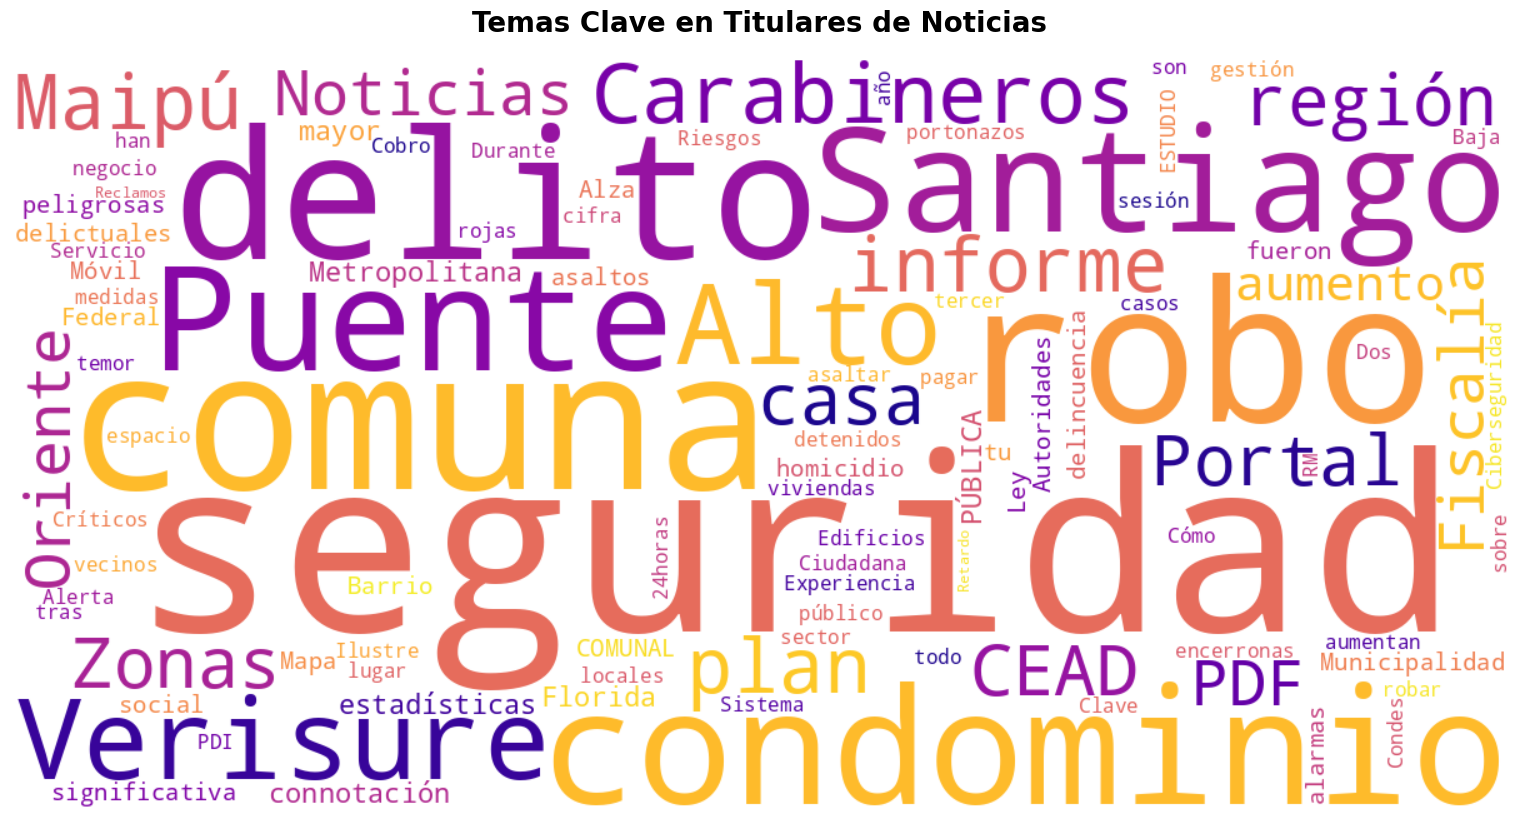

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Carga el archivo CSV que has subido
# Asegúrate de que la ruta sea la correcta
file_path = '/content/resultados_inteligencia_mercado.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Archivo '{file_path}' cargado exitosamente.")

    # Combinar todos los títulos en un solo texto
    text = " ".join(str(title) for title in df.titulo)

    # Definir palabras a ignorar (stopwords) en español
    stopwords = set([
        'de', 'la', 'el', 'en', 'y', 'a', 'los', 'del', 'las', 'un', 'una', 'para', 'con', 'por',
        'su', 'sus', 'que', 'es', 'se', 'no', 'lo', 'como', 'más', 'o', 'pero', 'este', 'esta', 'qué',
        'wom', 'claro', 'entel', 'movistar', 'chile', 'empresa', 'empresas'
    ])

    # Crear el objeto WordCloud con la configuración deseada
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=stopwords,
        collocations=False, # Evita mostrar pares de palabras
        colormap='plasma',
        max_words=100
    ).generate(text)

    # Mostrar y guardar la imagen generada
    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off') # No mostrar los ejes
    plt.title('Temas Clave en Titulares de Noticias', fontsize=20, weight='bold', pad=20)
    plt.tight_layout(pad=0)

    # Guardar la imagen en un archivo
    plt.savefig('wordcloud_titulares.png')
    print("¡Nube de palabras 'wordcloud_titulares.png' guardada exitosamente!")

except FileNotFoundError:
    print(f"Error: El archivo {file_path} no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

In [6]:
# prompt: guarda la imagen para descragar

from google.colab import files
files.download('wordcloud_titulares.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Este tipo de gráfico se llama Nube de Palabras o Mapa de Palabras (en inglés, Word Cloud). Su función es visualizar la frecuencia de las palabras en un texto; mientras más grande y central es una palabra, más veces aparece en los titulares que recopilamos.

Análisis Estratégico de la Nube de Palabras
Esta visualización es una radiografía de la conversación pública sobre seguridad en Santiago. Nos revela varias claves para un ejecutivo de ventas:

1. El Foco está en el Problema, no en la Solución
Las palabras más grandes y dominantes son delitos, seguridad, comuna y robos. Esto es una visión muy poderosa: la gente no está pensando en "alarmas" o "tecnología", está pensando en el problema fundamental y en cómo afecta a su entorno inmediato.

Recomendación: Tu discurso de ventas debe conectar emocionalmente con este "dolor". En lugar de empezar hablando de las características de tu alarma, empieza reconociendo la preocupación por la seguridad en su comuna.
Ejemplo: "Sabemos que la seguridad en la comuna es una prioridad para los vecinos..."
2. La Geografía es Clave: Puente Alto y Maipú en el Epicentro
Después de los términos genéricos, los nombres de comunas como Puente Alto y Maipú son extremadamente prominentes, seguidos de Santiago (como Santiago Centro) y Las Condes. Esto valida completamente nuestro mapa de calor anterior.

Recomendación: Estos no son solo datos, son tus territorios de venta prioritarios. La conversación sobre inseguridad es más intensa allí, por lo que la receptividad a una oferta de alarmas será probablemente mayor.
3. Verisure Domina la Mente del Consumidor
Verisure es la única marca de la competencia que aparece con un tamaño significativo. ADT es prácticamente invisible en esta nube.

Recomendación: Esto es una espada de doble filo.
Amenaza: Verisure es tu competidor principal y el primero que viene a la mente del cliente.
Oportunidad: Como ya descubrimos en los reclamos, su nombre está asociado tanto a seguridad como a "malas experiencias". Tu equipo de ventas debe estar preparado para nombrar a Verisure, conocer sus planes y contra-argumentar sus debilidades (contratos, servicio técnico, etc.).
4. La Conversación es "Oficial" y el Nicho de los Condominios es Real
Palabras como Carabineros, Fiscalía, informe y plan tienen un peso importante. Esto indica que las noticias se basan en fuentes oficiales, lo que les da credibilidad. Por otro lado, la palabra condominio destaca como un tipo de vivienda específico con una alta preocupación por la seguridad.

Recomendación:
Usa Datos Oficiales: Da más peso a tus argumentos de venta citando cifras de Carabineros o de la Subsecretaría de Prevención del Delito. Esto te posiciona como un experto informado, no solo como un vendedor.
Crea una Oferta para Condominios: La prominencia de esta palabra confirma que es un nicho de mercado de alto valor. Desarrollar un paquete específico para administraciones de condominios es una estrategia con altas probabilidades de éxito.
En resumen, tu análisis visual confirma que la estrategia de venta debe ser: hiper-local (enfocada en comunas específicas), basada en la emoción (abordando directamente el problema de la seguridad y los delitos), validada por datos oficiales (citando informes de Carabineros), y preparada para competir directamente con Verisure en los segmentos más atractivos como los condominios.

creado por Juan Alejandro Cuevas vasquez